In [1]:
from pathlib import Path
from itertools import combinations
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from IPython.display import display

warnings.filterwarnings("ignore")

if Path.cwd().name == "scripts":
    os.chdir("..")

BASE = Path.cwd().resolve()
MANIFEST_PATH = BASE / "data/raw/tcga/clinical/tcga_manifest.csv"
CLINICAL_PATH = BASE / "data/raw/tcga/clinical/tcga_clinical.csv"
SCANNER_PATH = BASE / "outputs/scanner_metadata/tcga_scanner_metadata.csv"
OUT = BASE / "outputs/tcga_calibration_curation"
OUT.mkdir(parents=True, exist_ok=True)

print("Project root:", BASE)
print("Output:", OUT)


Project root: /cs/student/project_msc/2025/aibh/mpapageo
Output: /cs/student/project_msc/2025/aibh/mpapageo/outputs/tcga_calibration_curation


In [2]:
df = pd.read_csv(MANIFEST_PATH)

df["case_id"] = df["case_id"].astype(str)
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["race"] = df["race"].fillna("not reported").astype(str).str.strip().str.lower()
df["sex"] = df["sex"].fillna("not reported").astype(str).str.strip().str.lower()
df["site"] = df["site"].fillna("Unknown").astype(str).str.strip()

clinical = pd.read_csv(CLINICAL_PATH)
if "case_id" not in clinical.columns:
    clinical["case_id"] = clinical["submitter_id"].astype(str).str[:12]

origin_cols = [c for c in clinical.columns if "tissue_or_organ_of_origin" in c]
clinical["tissue_origin"] = clinical[origin_cols].bfill(axis=1).iloc[:, 0] if origin_cols else np.nan
clinical_keep = [c for c in ["case_id", "idh_codel", "tissue_origin"] if c in clinical.columns]

df = df.merge(
    clinical[clinical_keep].drop_duplicates("case_id"),
    on="case_id", how="left", validate="one_to_one"
)

if SCANNER_PATH.exists():
    scanner = pd.read_csv(SCANNER_PATH)
    scanner["case_id"] = scanner["case_id"].astype(str)
    scanner_keep = [c for c in [
        "case_id", "vendor", "model", "objective_power",
        "mpp_x", "mpp_y", "software", "size_mb"
    ] if c in scanner.columns]
    df = df.merge(
        scanner[scanner_keep].drop_duplicates("case_id"),
        on="case_id", how="left", validate="one_to_one",
        suffixes=("", "_scanner")
    )

df["race_binary"] = np.select(
    [
        df["race"].eq("white"),
        ~df["race"].isin(["not reported", "unknown", "", "nan"]),
    ],
    ["white", "non-white"],
    default="not reported",
)

df["tumour_type"] = (
    df["tumour_type_who2021"]
    .fillna("unknown")
    .astype(str)
    .str.strip()
    .str.lower()
)

print("Cases:", len(df))
print("Centres:", df["site"].nunique())
display(df.head())


Cases: 789
Centres: 34


,case_id,project,file_id,file_name,size_mb,idh_status,idh_source,tumour_type_who2021,race,sex,...,tissue_origin,vendor,model,objective_power,mpp_x,mpp_y,software,size_mb_scanner,race_binary,tumour_type
0,TCGA-12-0819,TCGA-GBM,01116270-bf0e-44c1-bd77-033592e2a3e4,TCGA-12-0819-01Z-00-DX2.CA37F7BE-86D9-421F-B5A...,109.533596,wildtype,Mendonca2025_WHO2021,glioblastoma,black or african american,female,...,Not Reported,aperio,PATH-MCLEN001MS,20,0.4993,0.4993,20.0,109.533596,non-white,glioblastoma
1,TCGA-06-0208,TCGA-GBM,bb2e8ec8-6ff9-4b4b-99c8-dc2efe9fef5d,TCGA-06-0208-01Z-00-DX4.b377f84e-cc15-428c-802...,1508.850139,wildtype,Mendonca2025_WHO2021,glioblastoma,white,female,...,Not Reported,aperio,SS1258,20,0.5001,0.5001,20.0,1508.850139,white,glioblastoma
2,TCGA-02-0099,TCGA-GBM,b822fb8f-b9f7-4519-9db7-f86535ff5b6b,TCGA-02-0099-01Z-00-DX1.E3BD2989-346F-4580-9E6...,2799.729910,wildtype,Mendonca2025_WHO2021,glioblastoma,white,male,...,"Brain, NOS",aperio,SS7054,40,0.2533,0.2533,40.0,2799.729910,white,glioblastoma
3,TCGA-02-0024,TCGA-GBM,2e7e2d0a-55d8-4c9d-b064-e8e65051b0ec,TCGA-02-0024-01Z-00-DX1.d4cec60d-e2b6-41d1-92a...,199.221159,wildtype,Mendonca2025_WHO2021,glioblastoma,white,male,...,"Brain, NOS",aperio,SS1302,20,0.5015,0.5015,20.0,199.221159,white,glioblastoma
4,TCGA-06-0154,TCGA-GBM,33225646-c788-4d8c-b112-c69de7d8c27b,TCGA-06-0154-01Z-00-DX1.e52d5443-e663-451f-8a1...,536.873587,wildtype,Mendonca2025_WHO2021,glioblastoma,white,male,...,"Brain, NOS",aperio,SS1302,20,0.5040,0.5040,20.0,536.873587,white,glioblastoma


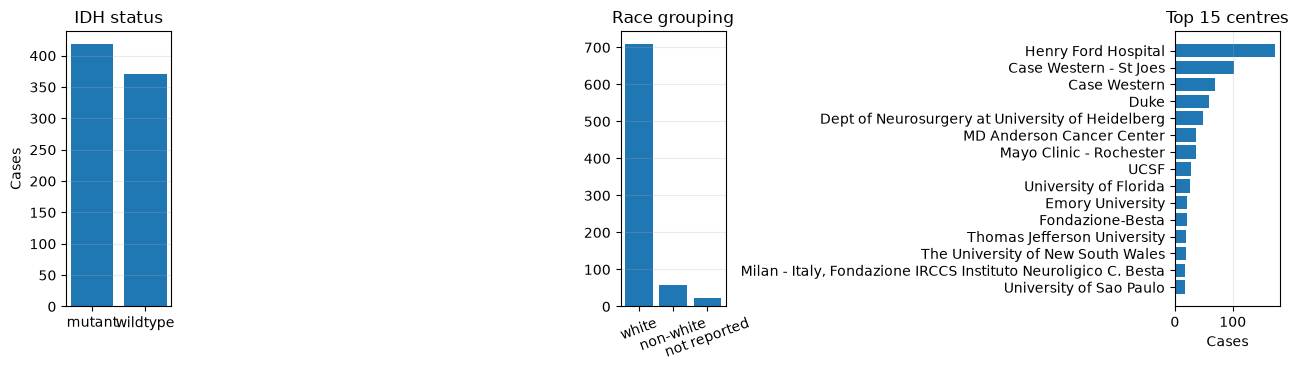

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

idh_counts = df["idh_status"].value_counts()
axes[0].bar(idh_counts.index, idh_counts.values)
axes[0].set_title("IDH status")
axes[0].set_ylabel("Cases")
axes[0].grid(axis="y", alpha=0.25)

race_counts = df["race_binary"].value_counts()
axes[1].bar(race_counts.index, race_counts.values)
axes[1].set_title("Race grouping")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.25)

site_counts = df["site"].value_counts().head(15)
axes[2].barh(site_counts.index[::-1], site_counts.values[::-1])
axes[2].set_title("Top 15 centres")
axes[2].set_xlabel("Cases")
axes[2].grid(axis="x", alpha=0.25)

fig.tight_layout()
plt.show()


In [4]:
def normalised_entropy(counts):
    counts = np.asarray(counts, dtype=float)
    counts = counts[counts > 0]
    if len(counts) <= 1:
        return 0.0
    p = counts / counts.sum()
    return float(-(p * np.log(p)).sum() / np.log(len(counts)))


def binary_balance_score(n_a, n_b):
    total = n_a + n_b
    if total == 0:
        return np.nan
    return float(1 - abs(n_a - n_b) / total)


def centre_summary_table(data):
    rows = []
    for site, sub in data.groupby("site"):
        n_mut = int((sub["idh_status"] == "mutant").sum())
        n_wt = int((sub["idh_status"] == "wildtype").sum())
        n_white = int((sub["race_binary"] == "white").sum())
        n_non_white = int((sub["race_binary"] == "non-white").sum())
        n_race_missing = int((sub["race_binary"] == "not reported").sum())
        tumour_counts = sub["tumour_type"].value_counts()

        rows.append({
            "site": site,
            "n": len(sub),
            "n_mutant": n_mut,
            "n_wildtype": n_wt,
            "pct_mutant": 100*n_mut/(n_mut+n_wt) if n_mut+n_wt else np.nan,
            "idh_balance": binary_balance_score(n_mut, n_wt),
            "n_white": n_white,
            "n_non_white": n_non_white,
            "n_race_not_reported": n_race_missing,
            "pct_non_white_known": 100*n_non_white/(n_white+n_non_white) if n_white+n_non_white else np.nan,
            "age_median": sub["age"].median(),
            "age_q1": sub["age"].quantile(0.25),
            "age_q3": sub["age"].quantile(0.75),
            "n_tumour_types": tumour_counts.size,
            "tumour_type_entropy": normalised_entropy(tumour_counts.values),
            "n_scanner_vendors": sub["vendor"].dropna().astype(str).nunique() if "vendor" in sub.columns else np.nan,
            "n_scanner_models": sub["model"].dropna().astype(str).nunique() if "model" in sub.columns else np.nan,
            "n_objective_powers": sub["objective_power"].dropna().nunique() if "objective_power" in sub.columns else np.nan,
            "median_mpp_x": pd.to_numeric(sub["mpp_x"], errors="coerce").median() if "mpp_x" in sub.columns else np.nan,
        })

    return pd.DataFrame(rows).sort_values(["n", "idh_balance"], ascending=[False, False]).reset_index(drop=True)

centre_summary = centre_summary_table(df)
display(centre_summary)
centre_summary.to_csv(OUT / "centre_summary.csv", index=False)


,site,n,n_mutant,n_wildtype,pct_mutant,idh_balance,n_white,n_non_white,n_race_not_reported,pct_non_white_known,age_median,age_q1,age_q3,n_tumour_types,tumour_type_entropy,n_scanner_vendors,n_scanner_models,n_objective_powers,median_mpp_x
0,Henry Ford Hospital,173,65,108,37.572254,0.751445,158,15,0,8.670520,55.0,43.00,64.00,4,0.748883,1,4,2,0.2526
1,Case Western - St Joes,103,82,21,79.611650,0.407767,97,6,0,5.825243,38.0,30.00,54.00,4,0.842384,1,5,1,0.2525
2,Case Western,69,34,35,49.275362,0.985507,61,8,0,11.594203,51.0,37.00,62.00,4,0.810842,1,7,1,0.2520
3,Duke,59,15,44,25.423729,0.508475,53,6,0,10.169492,55.0,45.00,63.00,3,0.606925,1,2,2,0.4993
4,Dept of Neurosurgery at University of Heidelberg,48,42,6,87.500000,0.250000,48,0,0,0.000000,42.5,34.75,52.00,4,0.765960,1,4,1,0.2527
5,MD Anderson Cancer Center,37,4,33,10.810811,0.216216,34,2,1,5.555556,50.0,40.00,59.00,3,0.422037,1,3,2,0.2533
6,Mayo Clinic - Rochester,37,33,4,89.189189,0.216216,33,0,4,0.000000,37.0,31.00,54.00,4,0.729477,1,2,1,0.2462
7,UCSF,28,1,27,3.571429,0.071429,18,1,9,5.263158,59.0,50.00,69.00,3,0.446427,1,2,2,0.2525
8,University of Florida,27,15,12,55.555556,0.888889,26,1,0,3.703704,52.0,43.00,65.00,4,0.857206,1,2,1,0.2485
9,Fondazione-Besta,21,17,4,80.952381,0.380952,20,1,0,4.761905,43.0,38.00,52.00,4,0.807625,1,2,1,0.2465


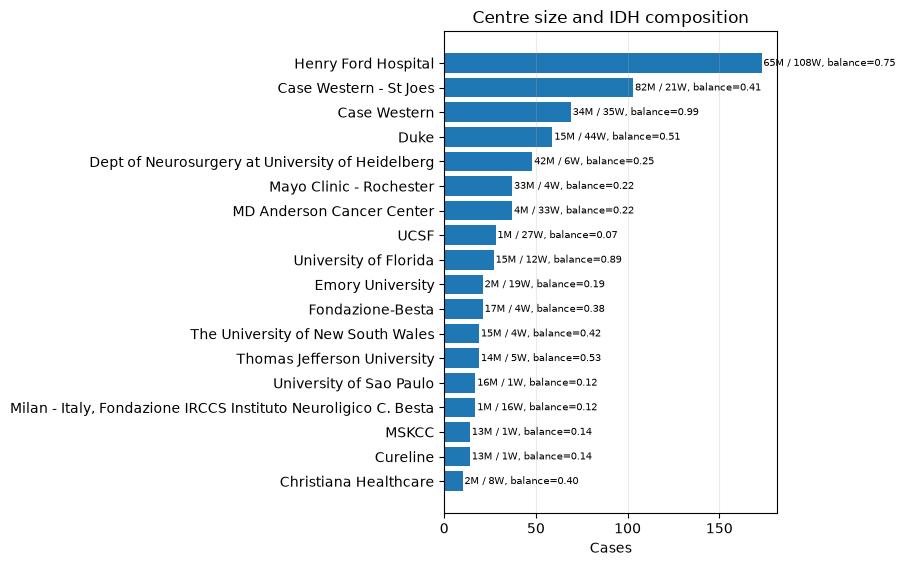

In [5]:
plot_df = centre_summary[centre_summary["n"] >= 10].sort_values("n", ascending=True)
fig, ax = plt.subplots(figsize=(9, max(5, 0.32 * len(plot_df))))
ax.barh(plot_df["site"], plot_df["n"])

for y, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row["n"] + 1, y,
        f"{int(row['n_mutant'])}M / {int(row['n_wildtype'])}W, balance={row['idh_balance']:.2f}",
        va="center", fontsize=7,
    )

ax.set_xlabel("Cases")
ax.set_title("Centre size and IDH composition")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


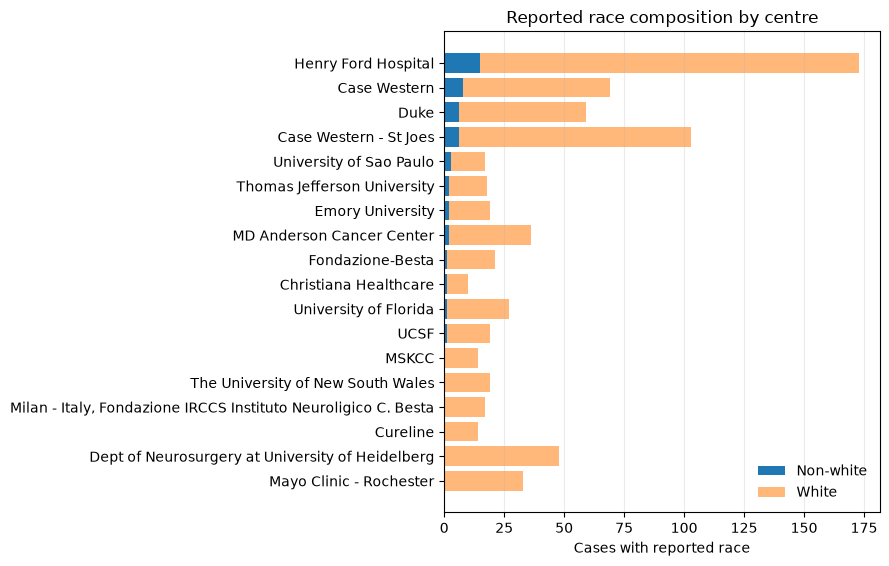

In [6]:
race_plot = centre_summary[centre_summary["n"] >= 10].sort_values("n_non_white", ascending=True)
fig, ax = plt.subplots(figsize=(9, max(5, 0.32 * len(race_plot))))
ax.barh(race_plot["site"], race_plot["n_non_white"], label="Non-white")
ax.barh(race_plot["site"], race_plot["n_white"], left=race_plot["n_non_white"], alpha=0.55, label="White")
ax.set_xlabel("Cases with reported race")
ax.set_title("Reported race composition by centre")
ax.legend(frameon=False)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()
